# Overview
This notebook tests the unconstrained MetaDoE PSO implementation against four standard optimization objectives in three dimensions and ten thousand dimensions.

# Optimization

In [ ]:
include("../../../src/MetaDoE.jl")
using .MetaDoE: Experiments, ConstraintEnforcement, Constraints, PSO, Objectives, Designs, Models, OptimizationRunner, HitAndRun

In [2]:
num_particles = 200
max_iters = 200
max_stag = 100
tolerance = 1e-6

runner_params = PSO.runner_params(max_iters, max_stag, tolerance)
pso_params = PSO.create_hyperparams(num_particles)

Main.MetaDoE.PSO.HyperParams(200, 0.7213475204444817, 1.1931471805599454, 1.1931471805599454, 3)

## 3D

In [3]:
N = 1
K = 3
objectives = [Objectives.ackley, Objectives.rastrigin, Objectives.rosenbrock, Objectives.griewank]
enforcers = [ConstraintEnforcement.None]
experiment = Experiments.create(N, K, Models.identity)

3

In [5]:
OptimizationRunner.run_pso_experiments(
    experiment,
    objectives, 
    enforcers, 
    runner_params,
    OptimizationRunner.save_3d_results(prefix="data/3d_unconstrained");
    log_iterations = false
)

PSO Context created for (ackley, None). Starting optimization...
PSO Context created for (griewank, None). Starting optimization...
PSO Context created for (rosenbrock, None). Starting optimization...
PSO Context created for (rastrigin, None). Starting optimization...
Optimization complete for (griewank, None). Saving results...
Optimization complete for (rosenbrock, None). Saving results...
Optimization complete for (rastrigin, None). Saving results...
Optimization complete for (ackley, None). Saving results...
Results saved. Best score for (rosenbrock, None): 0.014973931284963368
Results saved. Best score for (ackley, None): 1.0347278589506459e-13
Results saved. Best score for (rastrigin, None): 0.0
Results saved. Best score for (griewank, None): 0.0


## 10kD

In [6]:
N = 500
K = 20

20

In [7]:
objectives = [Objectives.ackley, Objectives.rastrigin, Objectives.rosenbrock, Objectives.griewank]
enforcers = [ConstraintEnforcement.None]
experiment = Experiments.create(N, K, Models.identity)

Main.MetaDoE.Experiments.Experiment(Dict("14" => 14, "4" => 4, "1" => 1, "12" => 12, "20" => 20, "2" => 2, "6" => 6, "7" => 7, "11" => 11, "13" => 13…), Main.MetaDoE.ConstraintEnforcement.NoConstraints(), Main.MetaDoE.Models.var"#40#41"(), 500, 20)

In [8]:
OptimizationRunner.run_pso_experiments(
    experiment,
    objectives, 
    enforcers, 
    runner_params,
    OptimizationRunner.save_3d_results(prefix="data/10kd_unconstrained");
    log_iterations = false
)

PSO Context created for (rosenbrock, None). Starting optimization...
PSO Context created for (griewank, None). Starting optimization...
PSO Context created for (ackley, None). Starting optimization...
PSO Context created for (rastrigin, None). Starting optimization...
Optimization complete for (rosenbrock, None). Saving results...
Optimization complete for (griewank, None). Saving results...
Results saved. Best score for (griewank, None): 1.1102230246251565e-16
Results saved. Best score for (rosenbrock, None): 9499.571104189466
Optimization complete for (ackley, None). Saving results...
Optimization complete for (rastrigin, None). Saving results...
Results saved. Best score for (ackley, None): 2.1895818491657337e-11
Results saved. Best score for (rastrigin, None): 0.0


# Visualization

In [ ]:
from metadoe.visualization.convergence import plot_scores
import numpy as np
import itertools
from metadoe.visualization.phate import apply_phate, plot_phate

## Convergence Plots

### 3D

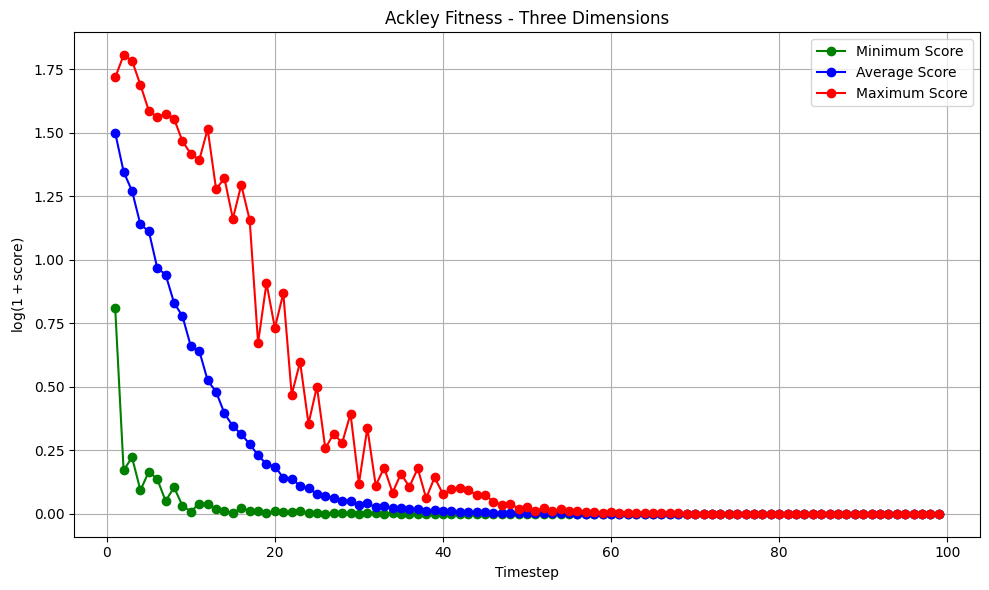

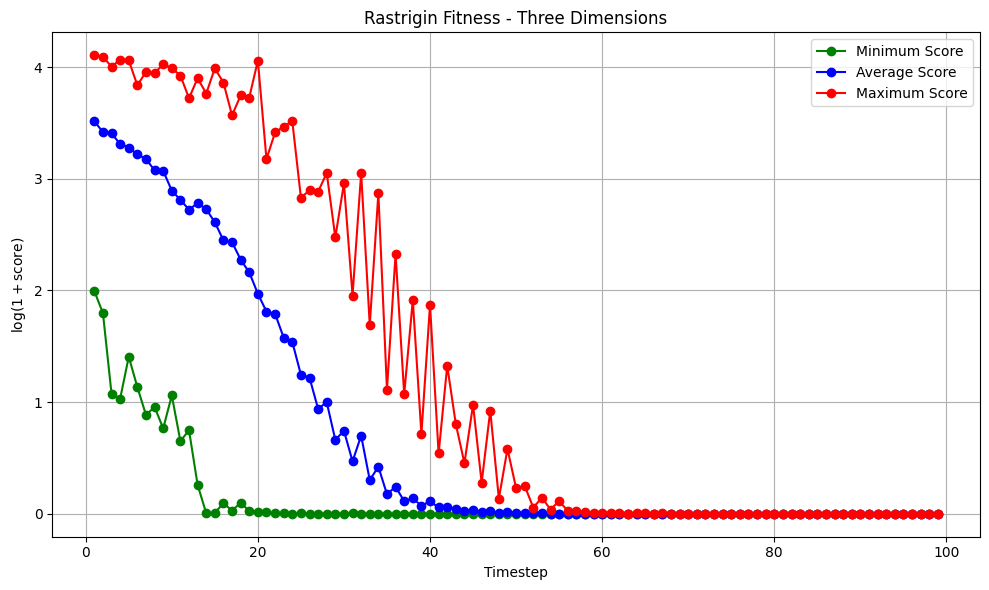

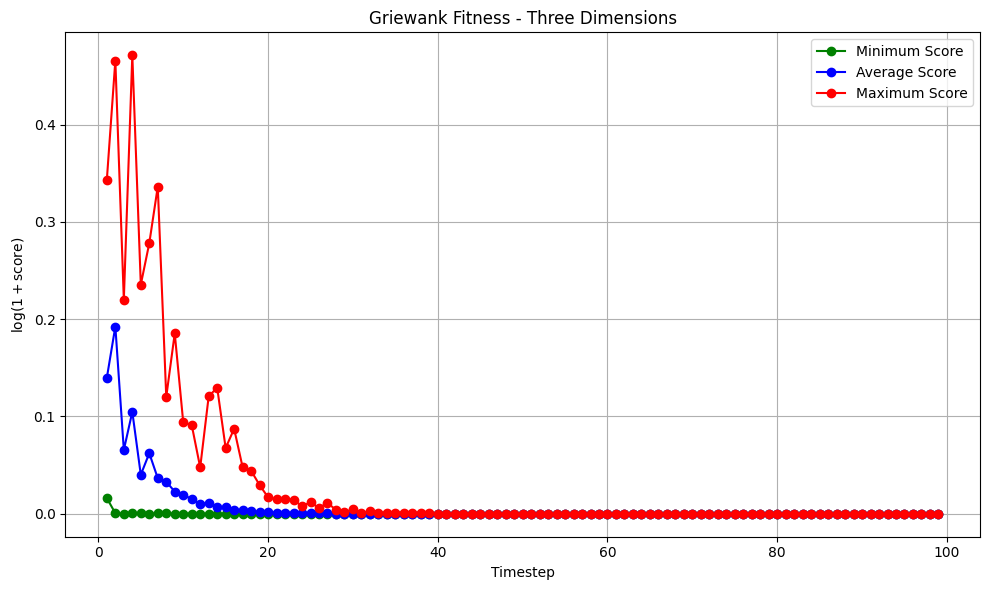

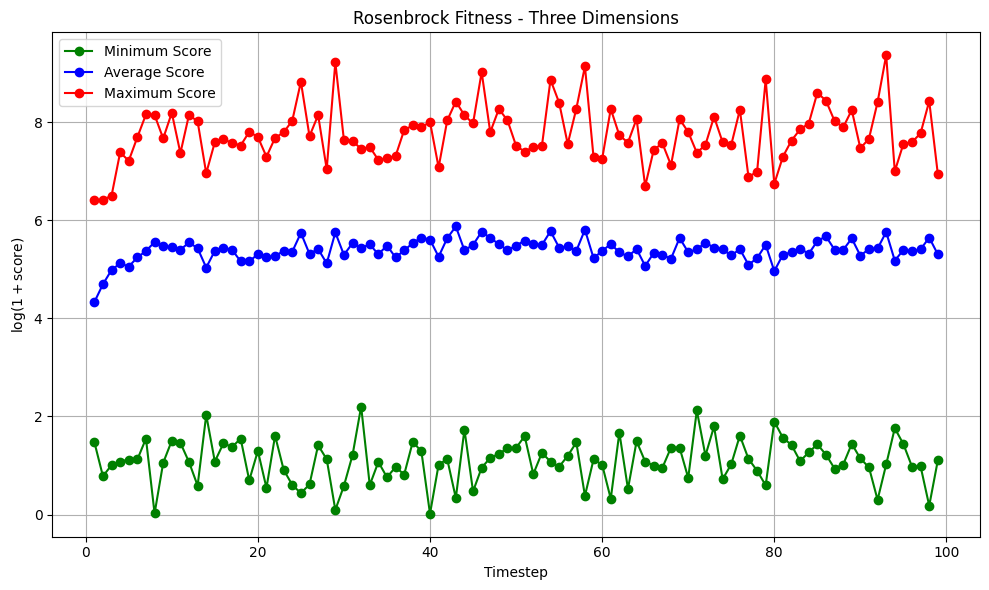

In [5]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['None']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    data = np.load(f'data/3d_unconstrained_{objective}_{enforcer}.npy')
    scores = data['scores']
    plot_scores(scores, 1, 100, f"{objective.capitalize()} Fitness - Three Dimensions", f"plots/3d_unconstrained_{objective}_{enforcer}")

### 10kd

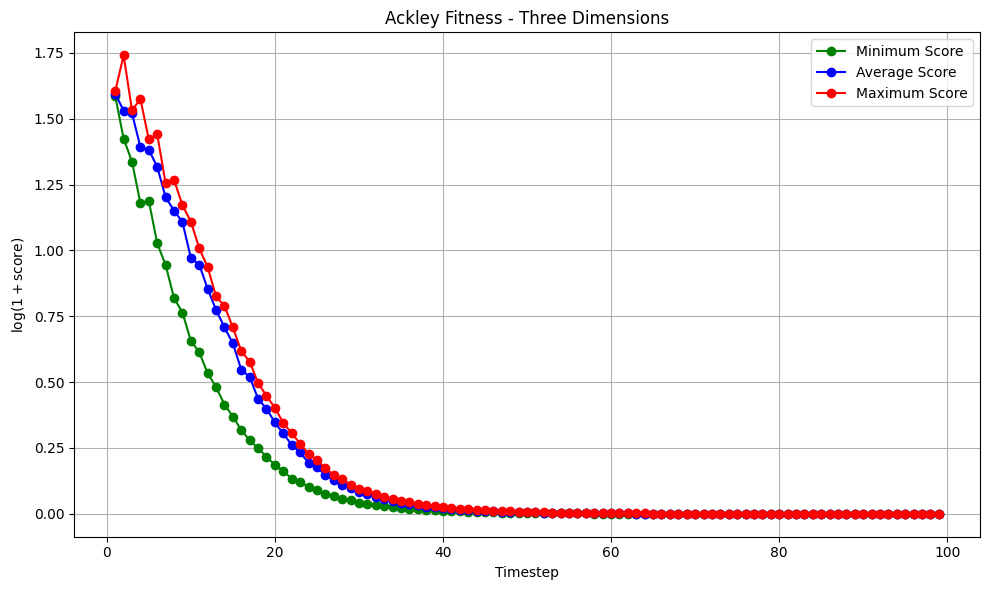

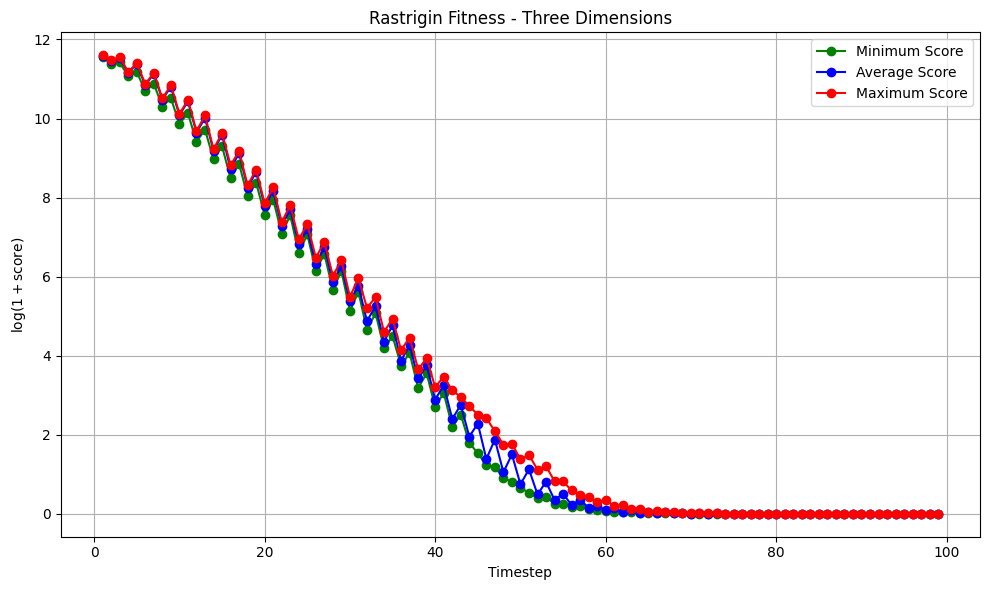

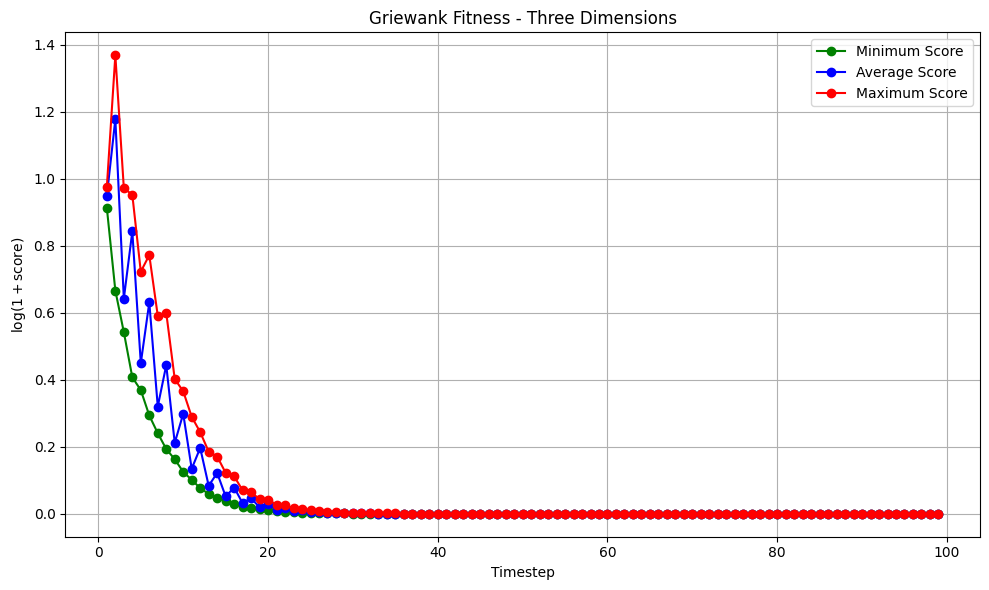

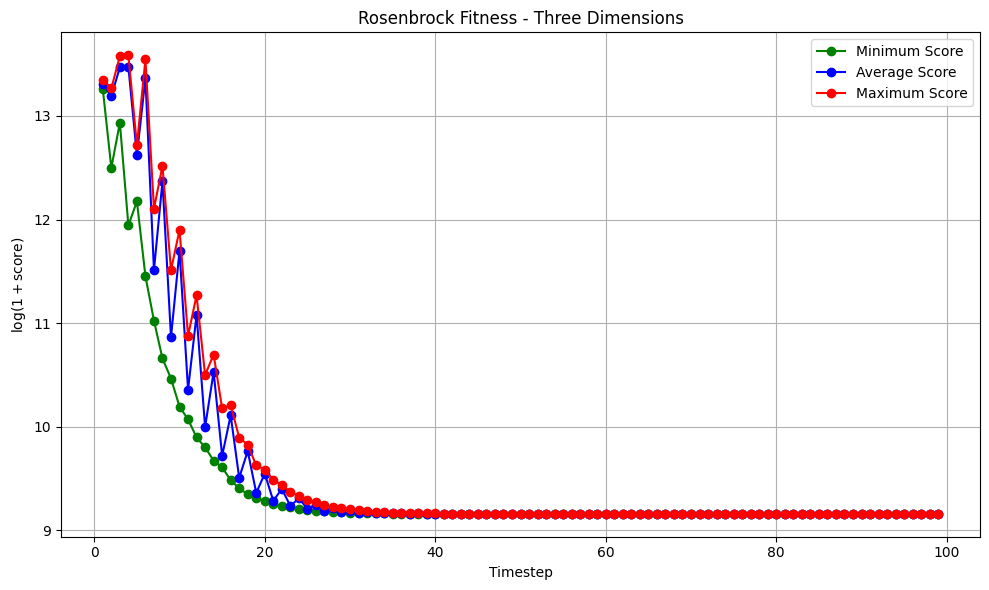

In [4]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['None']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    data = np.load(f'data/10kd_unconstrained_{objective}_{enforcer}.npy')
    scores = data['scores']
    plot_scores(scores, 1, 100, f"{objective.capitalize()} Fitness - Three Dimensions", f"plots/10kd_unconstrained_{objective}_{enforcer}")

## PHATE Plots

### 3D

Calculating PHATE...
  Running PHATE on 17800 observations and 3 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.13 seconds.
    Calculating affinities...
    Calculated affinities in 0.12 seconds.
  Calculated graph and diffusion operator in 0.26 seconds.
  Calculating landmark operator...
    Calculating SVD...


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 100 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated SVD in 0.30 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.89 seconds.
  Calculated landmark operator in 2.19 seconds.
  Calculating optimal t...
    Automatically selected t = 29
  Calculated optimal t in 0.49 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.58 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.08 seconds.
Calculated PHATE in 4.93 seconds.


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Calculating PHATE...
  Running PHATE on 14500 observations and 3 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.09 seconds.
    Calculating affinities...
    Calculated affinities in 0.11 seconds.
  Calculated graph and diffusion operator in 0.20 seconds.
  Calculating landmark operator...
    Calculating SVD...


...

/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


    Calculated KNN search in 0.08 seconds.
    Calculating affinities...
    Calculated affinities in 0.11 seconds.
  Calculated graph and diffusion operator in 0.19 seconds.
  Calculating landmark operator...
    Calculating SVD...


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 99 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated SVD in 0.24 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.92 seconds.
  Calculated landmark operator in 2.16 seconds.
  Calculating optimal t...
    Automatically selected t = 51
  Calculated optimal t in 0.49 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.62 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.10 seconds.
Calculated PHATE in 4.85 seconds.


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


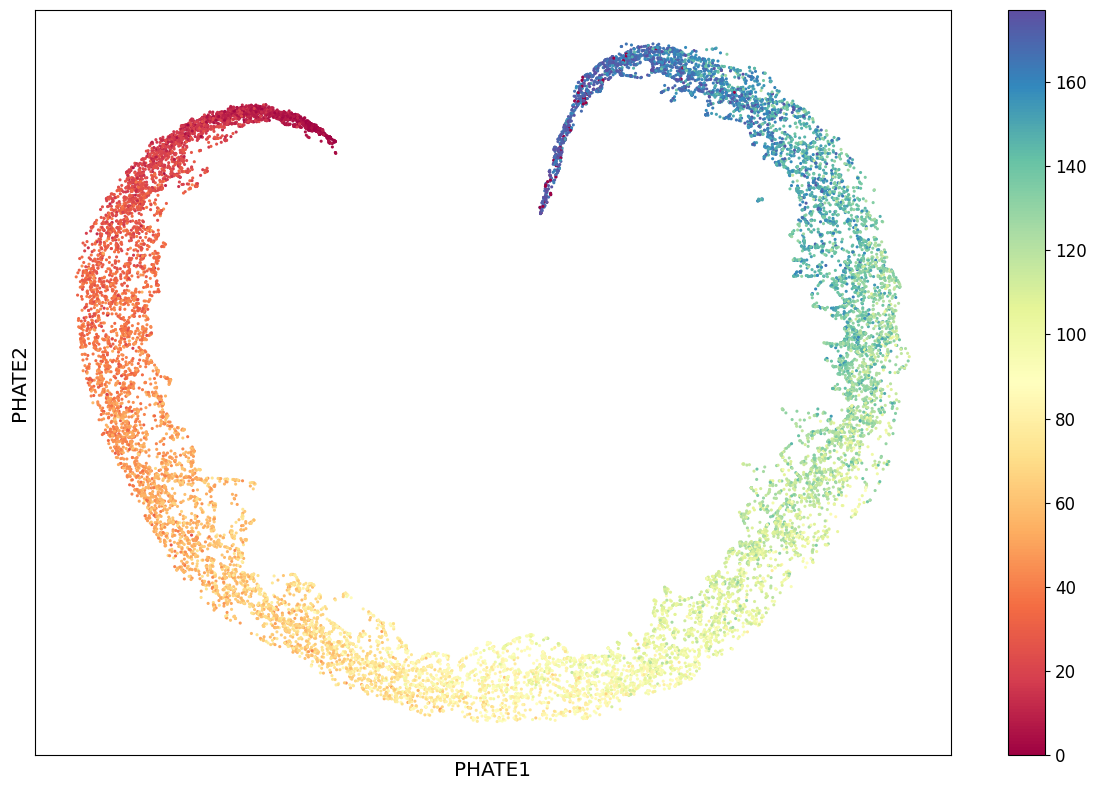

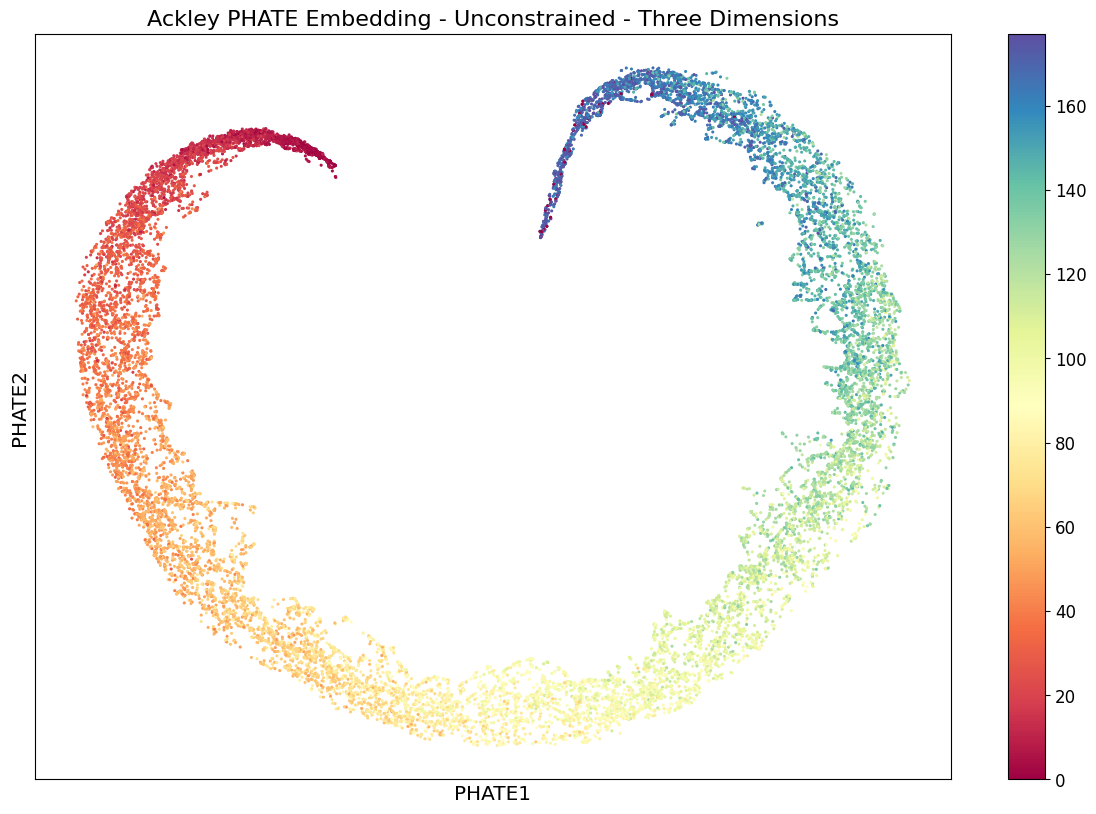

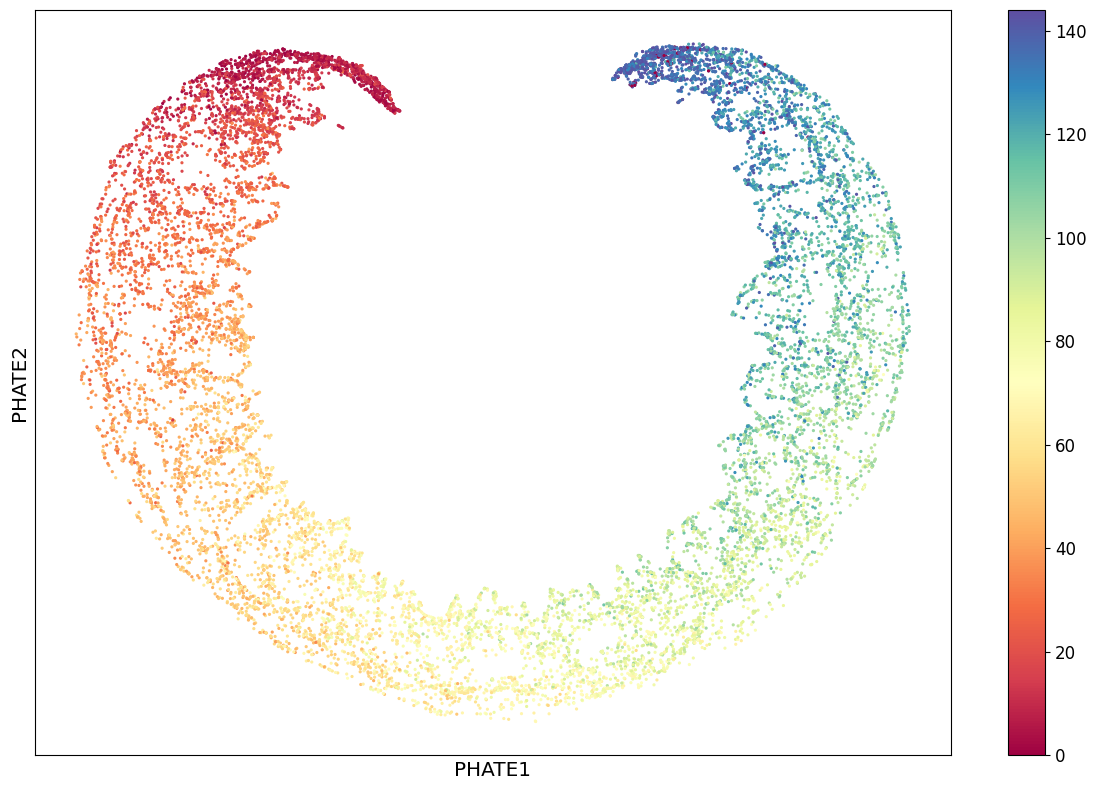

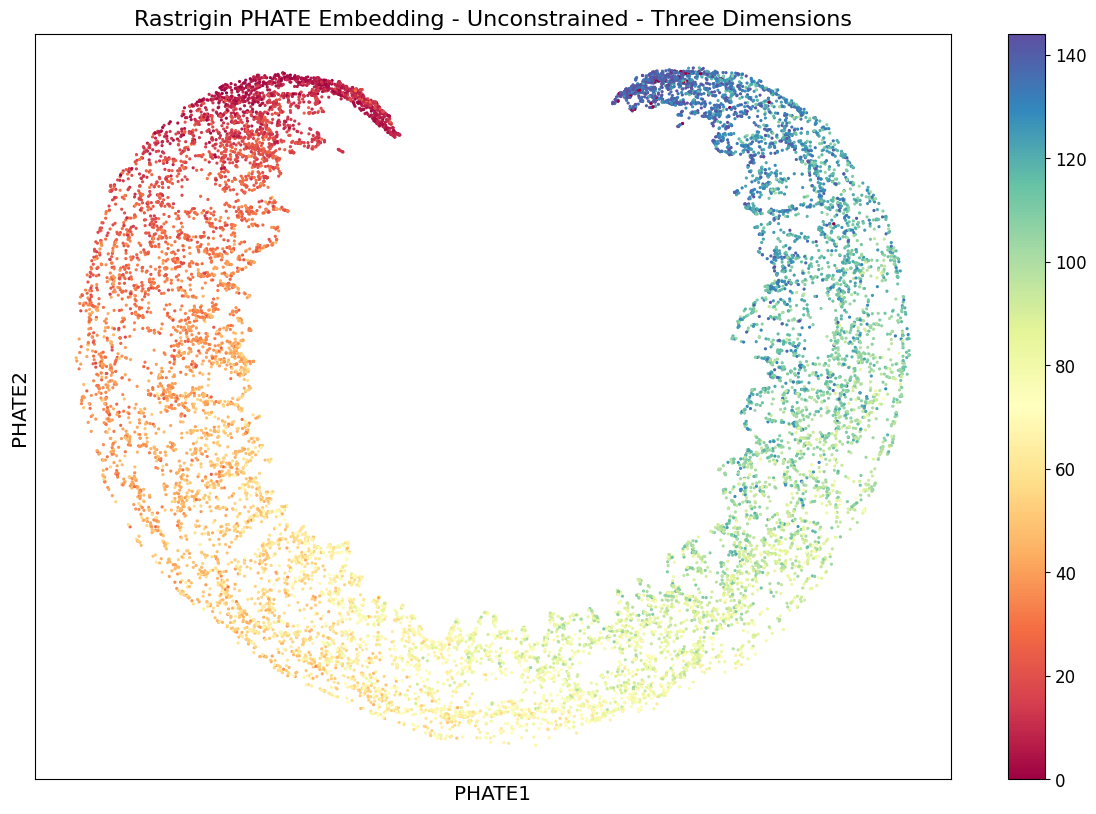

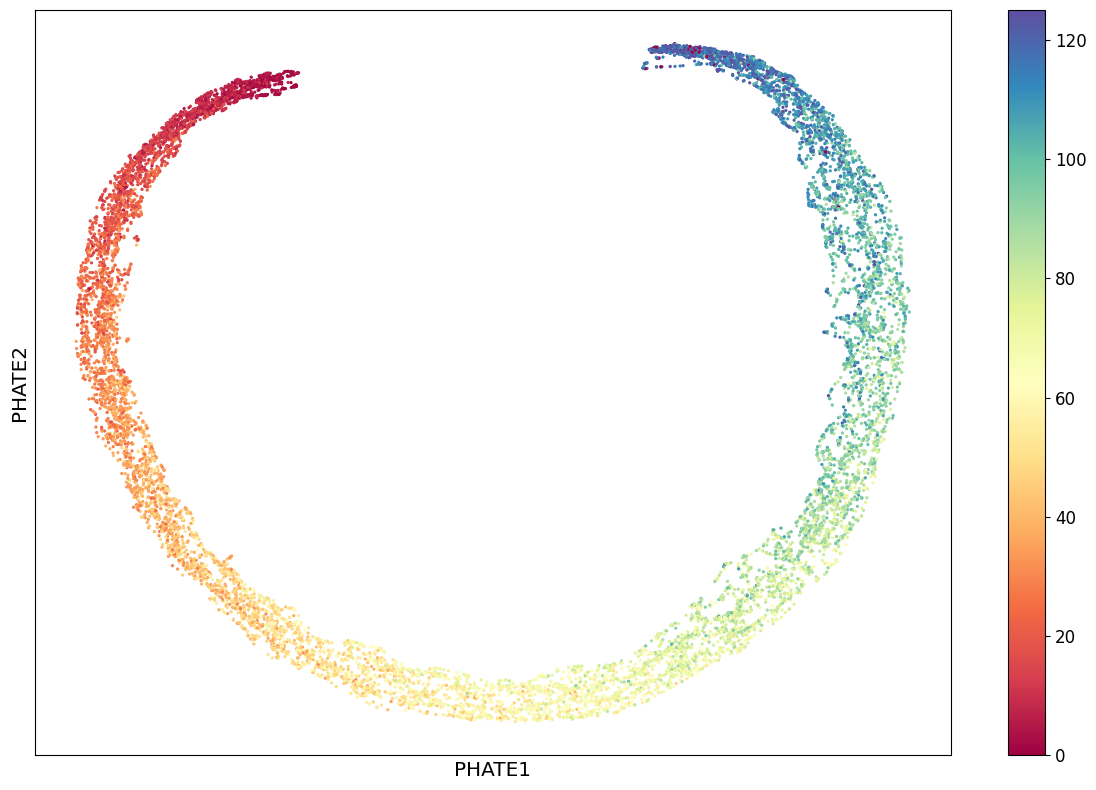

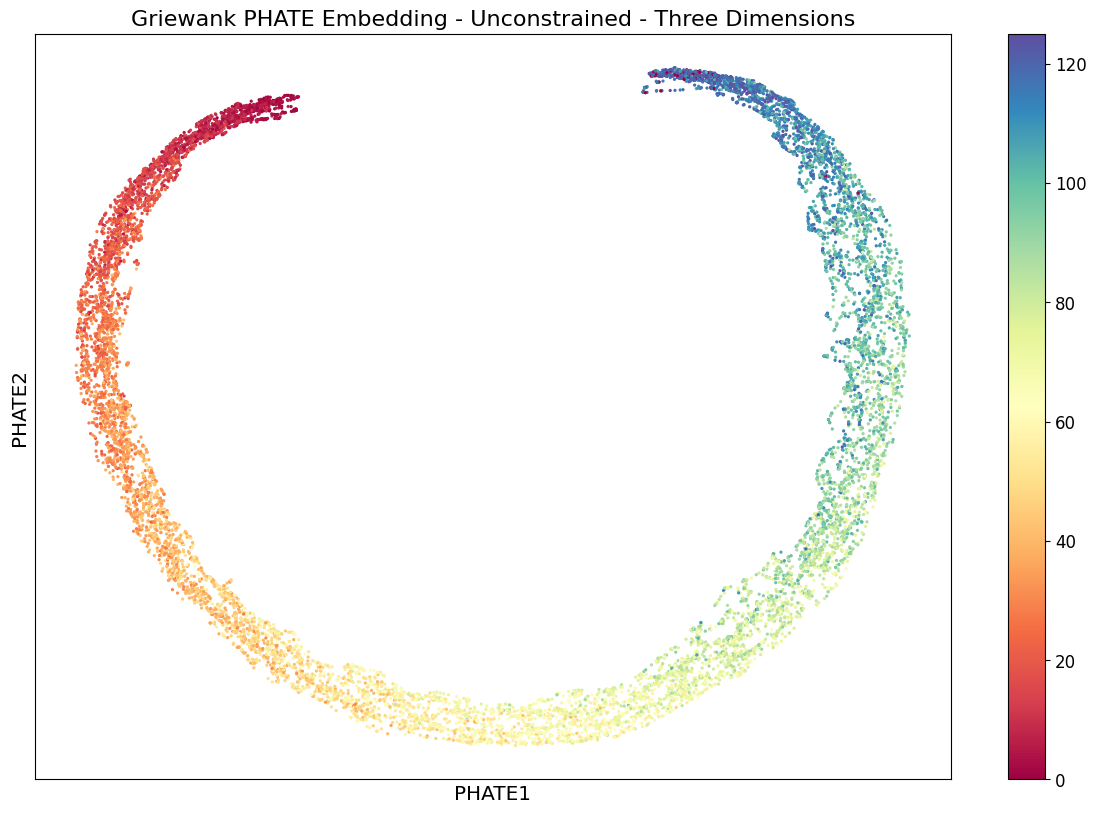

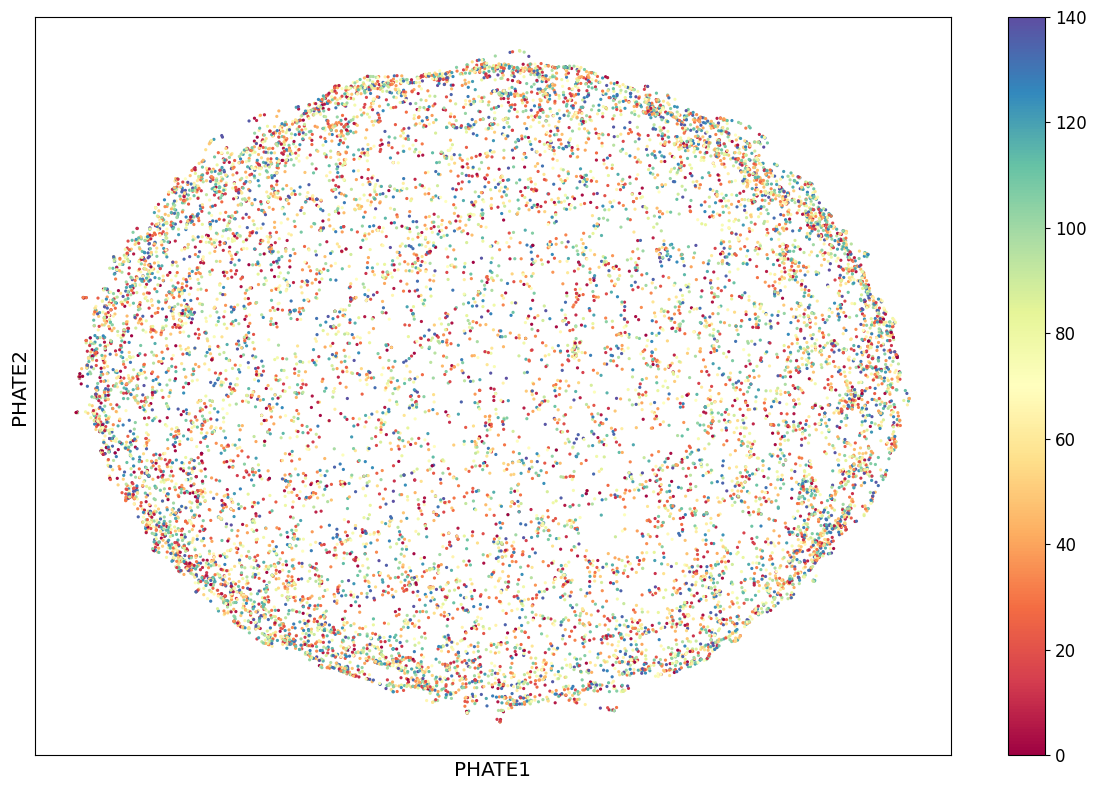

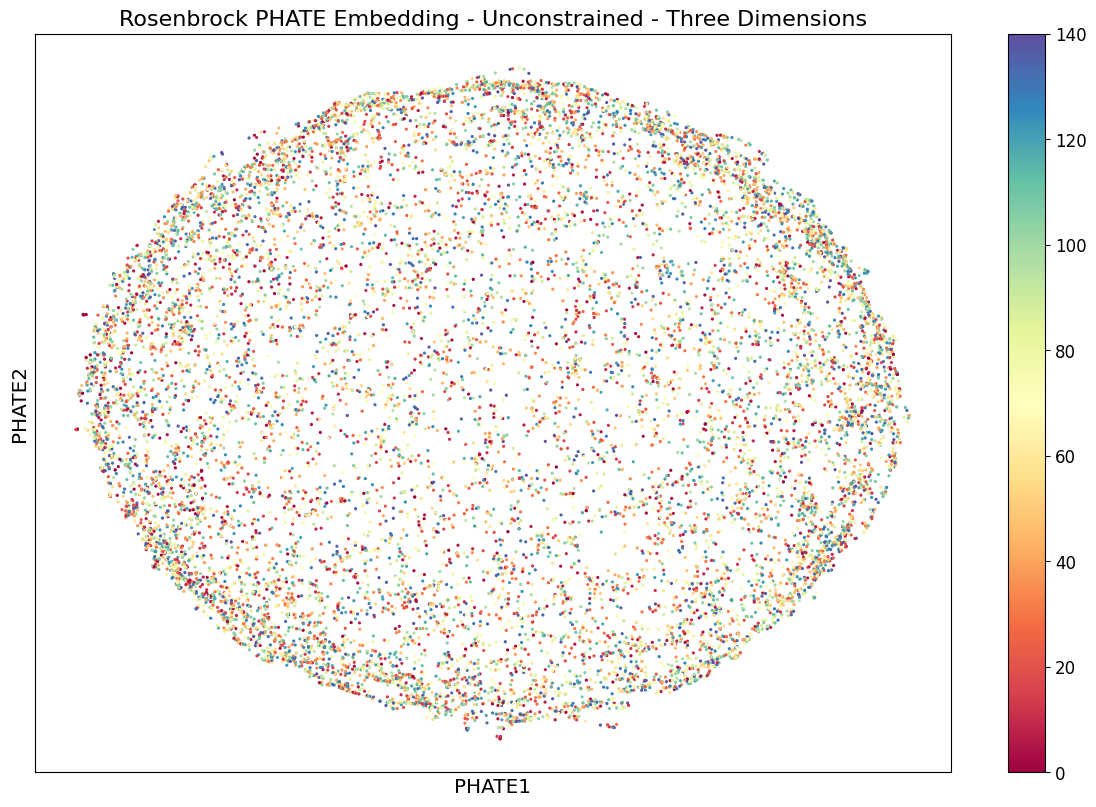

In [7]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['None']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    # Load the data
    file_loc = f'data/3d_unconstrained_{objective}_{enforcer}.npy'

    # Apply phate
    Y_phate, time = apply_phate(file_loc)

    # Plot the PHATE embedding
    title = f"{objective.capitalize()} PHATE Embedding - Unconstrained - Three Dimensions"
    prefix = f"plots/3d_unconstrained_{objective}_{enforcer}"
    plot_phate(Y_phate, time, title, prefix)

### 10kD

Calculating PHATE...
  Running PHATE on 19700 observations and 10000 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.63 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.21 seconds.
    Calculating affinities...


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 78616 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:506: RuntimeWarning: overflow encountered in power
  weights = np.exp(-np.power(scaled, decay))


    Calculated affinities in 4.31 seconds.


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/base.py:554: RuntimeWarning: K should have a non-zero diagonal
  warnings.warn("K should have a non-zero diagonal", RuntimeWarning)


  Calculated graph and diffusion operator in 10.94 seconds.
  Calculating landmark operator...
    Calculating SVD...


...

/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Calculating PHATE...
  Running PHATE on 18900 observations and 10000 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.02 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.24 seconds.
    Calculating affinities...


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 61 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.99 seconds.
  Calculated graph and diffusion operator in 6.64 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 7.35 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.02 seconds.
  Calculated landmark operator in 9.38 seconds.
  Calculating optimal t...
    Automatically selected t = 9
  Calculated optimal t in 0.46 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.30 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -2.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.16 seconds.
Calculated PHATE in 20.55 seconds.


/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/ben/Code/MetaDoE/.venv/lib/python3.11/site-packages/scprep/plot/utils.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


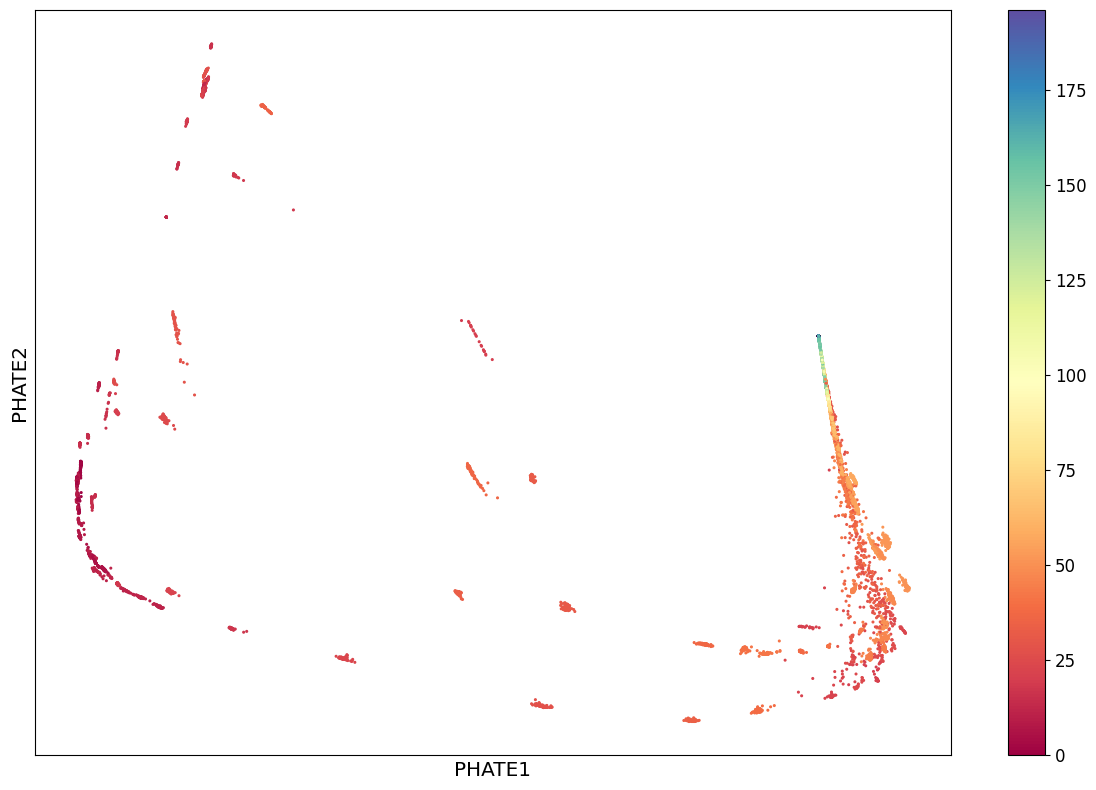

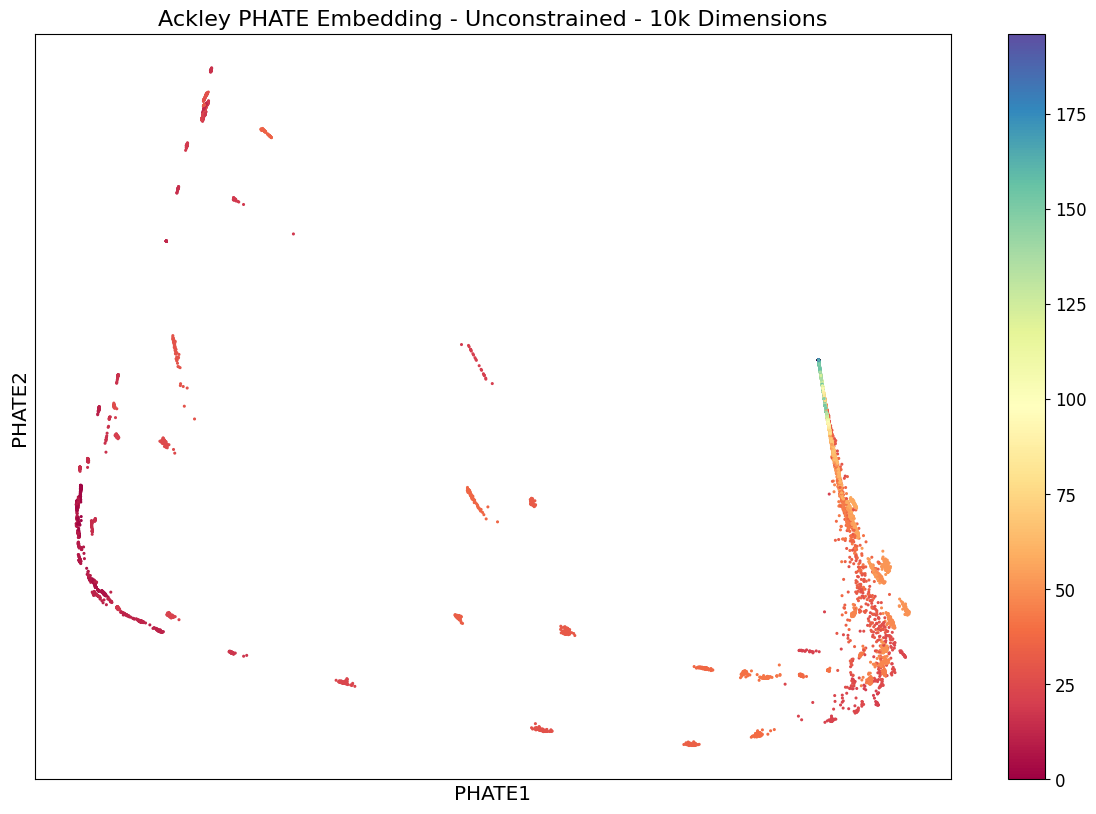

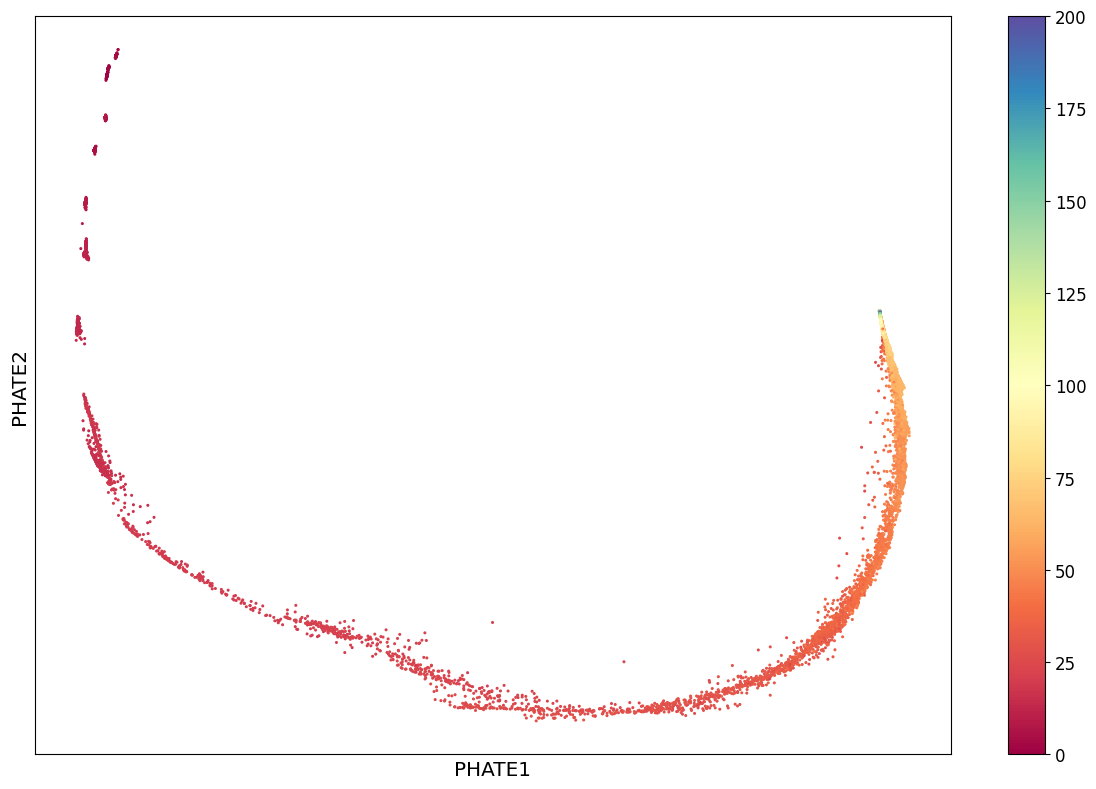

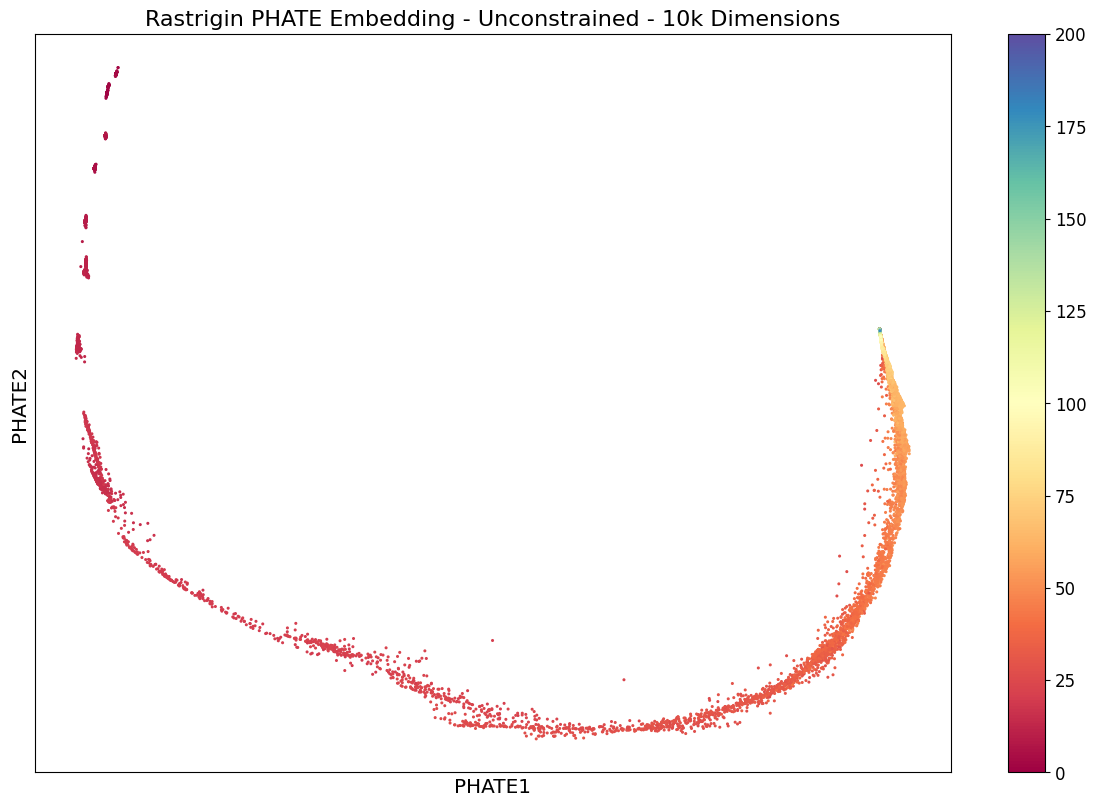

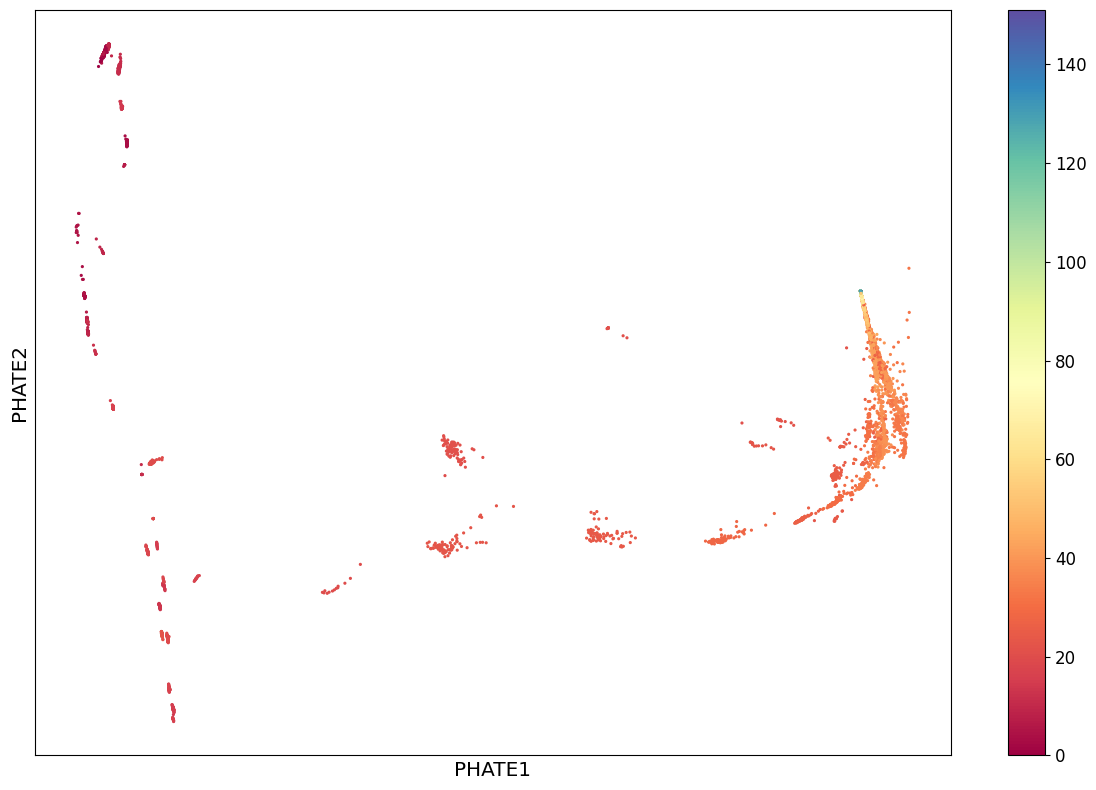

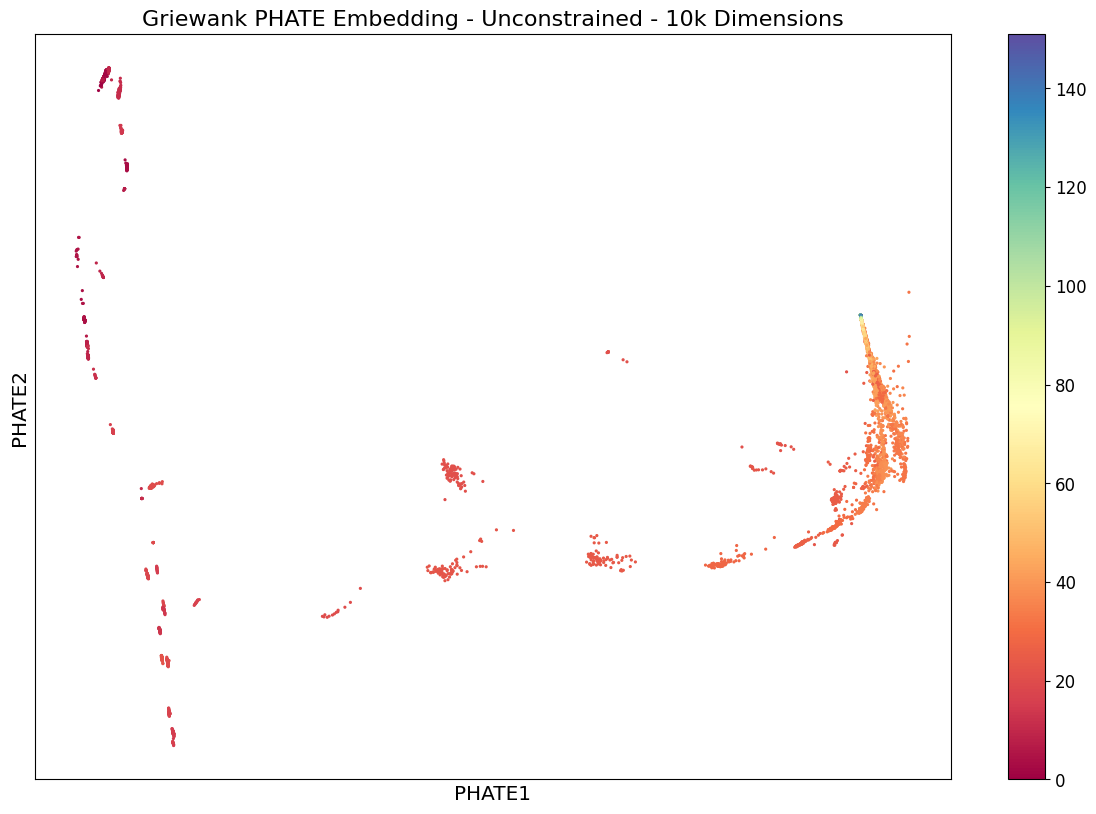

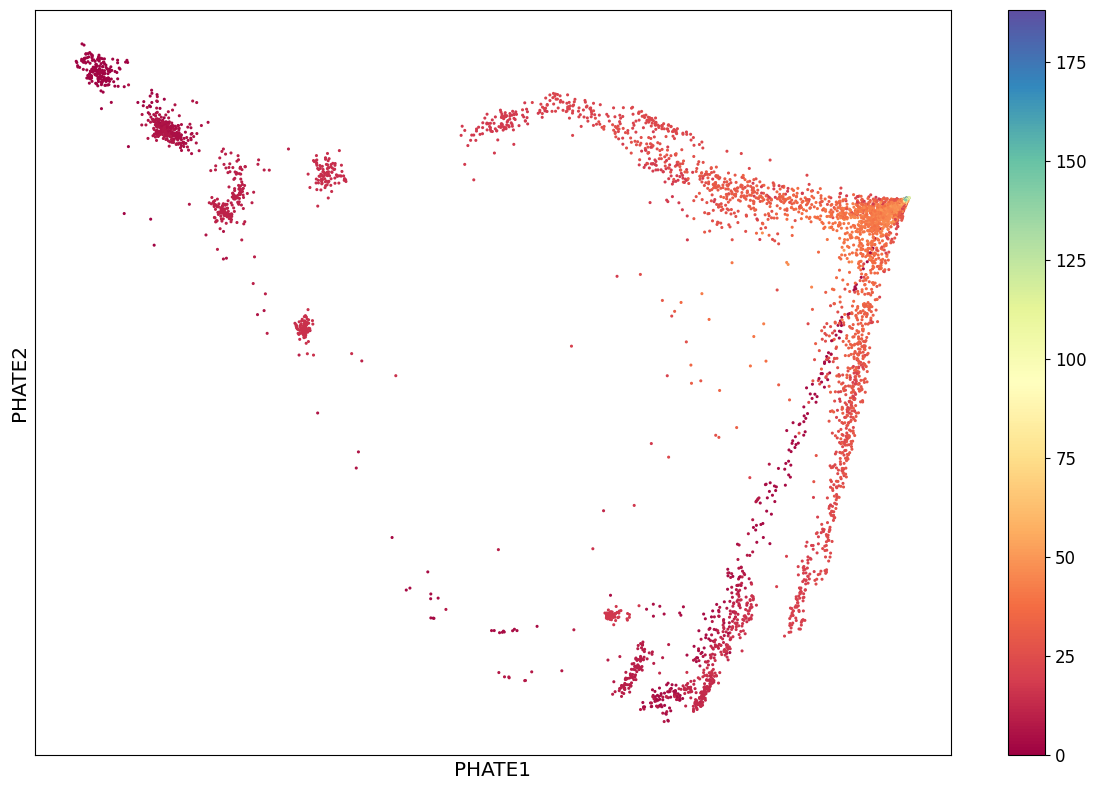

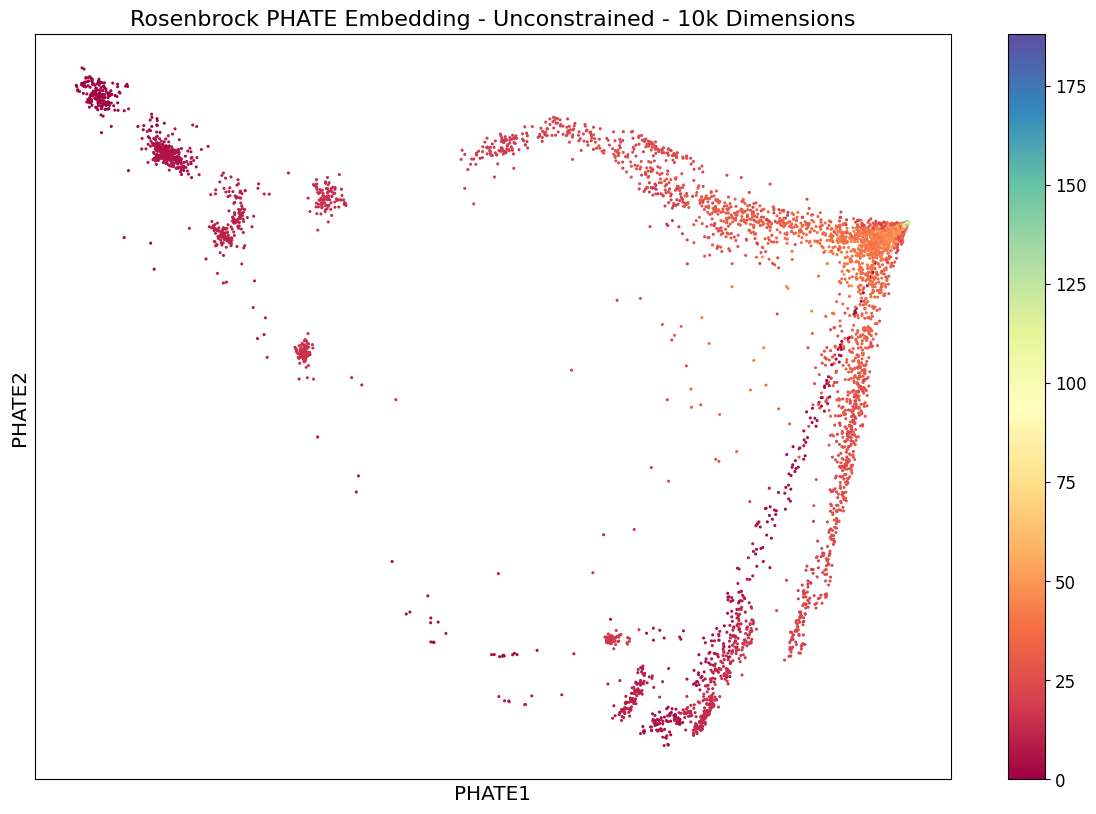

In [8]:
objectives = ['ackley', 'rastrigin', 'griewank', 'rosenbrock']
enforcers = ['None']
combos = list(itertools.product(objectives, enforcers))

for (objective, enforcer) in combos:
    # Load the data
    file_loc = f'data/10kd_unconstrained_{objective}_{enforcer}.npy'

    # Apply phate
    Y_phate, time = apply_phate(file_loc)

    # Plot the PHATE embedding
    title = f"{objective.capitalize()} PHATE Embedding - Unconstrained - 10k Dimensions"
    prefix = f"plots/10kd_unconstrained_{objective}_{enforcer}"
    plot_phate(Y_phate, time, title, prefix)